In [12]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

print("Libraries loaded")

Libraries loaded


In [13]:
class SocialMedia():
    def __init__(self, num_agents, sns_seed, num_bridge):
        self.num_agents = num_agents
        np.random.seed(sns_seed)

        # Create two complete graphs (groups)
        self.G = nx.erdos_renyi_graph(num_agents, 1)
        H = nx.erdos_renyi_graph(num_agents, 1)

        # Relabel nodes in group H
        mapping = {k: k + num_agents for k in H.nodes()}
        H = nx.relabel_nodes(H, mapping)

        # Merge G and H
        self.F = nx.compose(self.G, H)

        # Add bridges
        pickedG = np.random.choice(list(self.G.nodes()), num_bridge, replace=False)
        pickedH = np.random.choice(list(H.nodes()), num_bridge, replace=False)
        for i in range(num_bridge):
            self.F.add_edge(pickedG[i], pickedH[i])

    def run(self, p=0.5, time_steps=300):
        nodes = list(self.F.nodes())
        n = len(nodes)

        # Set initial opinions
        for i in nodes:
            self.F.nodes[i]['opinion'] = np.random.binomial(1, p)

        history = []

        B = np.array(nx.adjacency_matrix(self.F).todense())

        for t in range(time_steps):
            all_op = np.array([self.F.nodes[i]['opinion'] for i in nodes])
            history.append(int(all_op.sum()))

            # Check convergence
            if all_op.sum() == 0 or all_op.sum() == n:
                break

            # Update opinions
            p_list = []
            for u in range(n):
                row = B[u].copy()
                row[u] = 1  # Include own opinion
                nx_p = np.dot(row, all_op) / row.sum()
                p_list.append(nx_p)

            for i, node in enumerate(nodes):
                self.F.nodes[node]['opinion'] = np.random.binomial(1, p_list[i])

        return history

print("Class defined")

Class defined


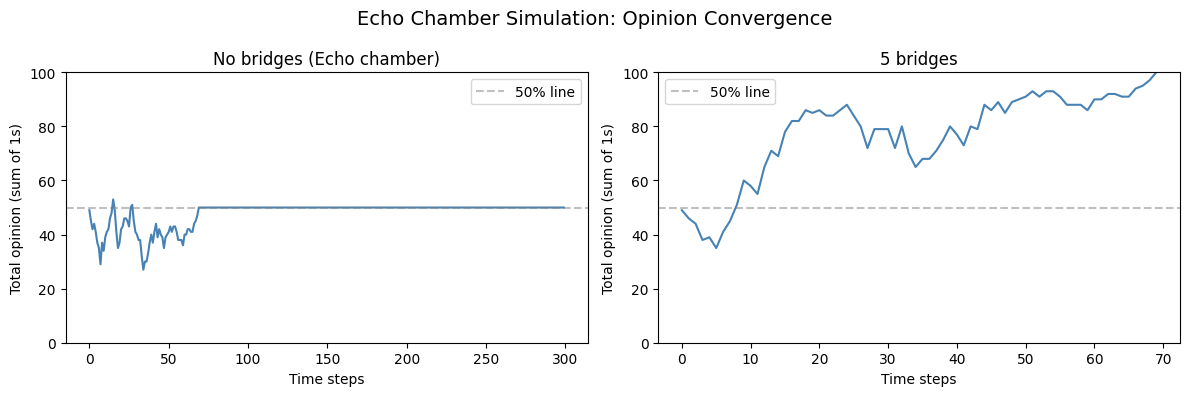

Graph displayed


In [14]:
# Run simulation (with and without bridges)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, num_bridge, title in zip(
    axes,
    [0, 5],
    ["No bridges (Echo chamber)", "5 bridges"]
):
    model = SocialMedia(num_agents=50, sns_seed=42, num_bridge=num_bridge)
    history = model.run()

    ax.plot(history, color='steelblue')
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% line')
    ax.set_title(title)
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Total opinion (sum of 1s)")
    ax.set_ylim(0, 100)
    ax.legend()

plt.suptitle("Echo Chamber Simulation: Opinion Convergence", fontsize=14)
plt.tight_layout()
plt.show()

print("Graph displayed")

In [15]:
def calc_convergence_rate(num_agents, num_bridge, trials=100, time_steps=300):
    converged = 0
    for seed in range(trials):
        model = SocialMedia(num_agents=num_agents, sns_seed=seed, num_bridge=num_bridge)
        history = model.run(time_steps=time_steps)
        # Check if converged (all 0 or all 1)
        if history[-1] == 0 or history[-1] == num_agents * 2:
            converged += 1
    return converged / trials

# Test bridge counts from 0 to 40 in steps of 5
bridge_counts = list(range(0, 41, 5))
convergence_rates = []

for b in bridge_counts:
    rate = calc_convergence_rate(num_agents=50, num_bridge=b)
    print(f"Bridges {b}: Convergence rate {rate:.2f}")
    convergence_rates.append(rate)

print("Calculation complete")

Bridges 0: Convergence rate 0.40
Bridges 5: Convergence rate 0.66
Bridges 10: Convergence rate 0.68
Bridges 15: Convergence rate 0.75
Bridges 20: Convergence rate 0.80
Bridges 25: Convergence rate 0.84
Bridges 30: Convergence rate 0.86
Bridges 35: Convergence rate 0.89
Bridges 40: Convergence rate 0.88
Calculation complete


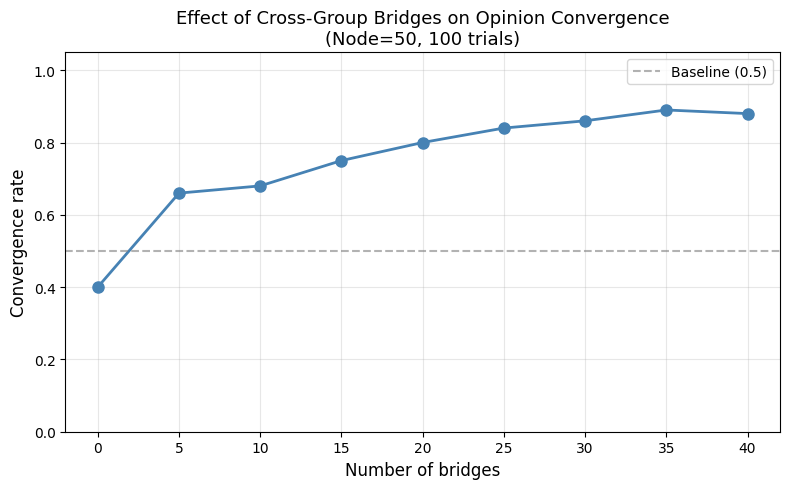

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(bridge_counts, convergence_rates,
        marker='o', color='steelblue', linewidth=2, markersize=8)

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.6, label='Baseline (0.5)')
ax.set_xlabel("Number of bridges", fontsize=12)
ax.set_ylabel("Convergence rate", fontsize=12)
ax.set_title("Effect of Cross-Group Bridges on Opinion Convergence\n(Node=50, 100 trials)", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
node_settings = [
    (10, 60, list(range(0, 9, 1))),
    (30, 180, list(range(0, 25, 2))),
    (50, 300, list(range(0, 41, 5))),
    (100, 600, list(range(0, 81, 10))),
]

results = {}

for num_agents, time_steps, bridges in node_settings:
    rates = []
    for b in bridges:
        rate = calc_convergence_rate(
            num_agents=num_agents,
            num_bridge=b,
            trials=100,
            time_steps=time_steps
        )
        rates.append(rate)
    results[num_agents] = (bridges, rates)
    print(f"Node {num_agents} complete")

print("All calculations complete")

Node 10 complete
Node 30 complete
Node 50 complete
Node 100 complete
All calculations complete


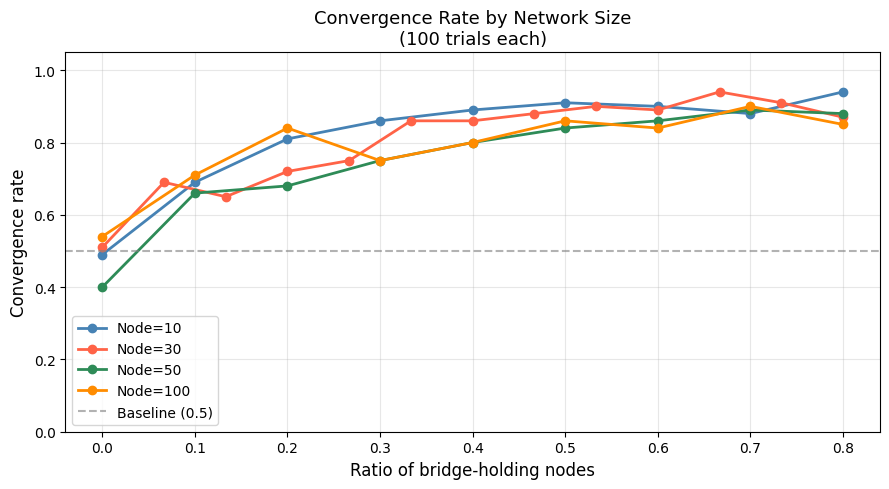

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

for (num_agents, (bridges, rates)), color in zip(results.items(), colors):
    ratio = [b / num_agents for b in bridges]
    ax.plot(ratio, rates, marker='o', color=color, linewidth=2, markersize=6, label=f'Node={num_agents}')

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.6, label='Baseline (0.5)')
ax.set_xlabel("Ratio of bridge-holding nodes", fontsize=12)
ax.set_ylabel("Convergence rate", fontsize=12)
ax.set_title("Convergence Rate by Network Size\n(100 trials each)", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
def calc_convergence_time(num_agents, num_bridge, trials=100, time_steps=300):
    times = []
    for seed in range(trials):
        model = SocialMedia(num_agents=num_agents, sns_seed=seed, num_bridge=num_bridge)
        history = model.run(time_steps=time_steps)
        # Record time only if converged
        if history[-1] == 0 or history[-1] == num_agents * 2:
            times.append(len(history))
    # Return average time of converged trials
    return np.mean(times) if times else None

node_settings_time = [
    (10, 60, list(range(0, 9, 1))),
    (30, 180, list(range(0, 25, 2))),
    (50, 300, list(range(0, 41, 5))),
    (100, 600, list(range(0, 81, 10))),
]

time_results = {}

for num_agents, time_steps, bridges in node_settings_time:
    times = []
    for b in bridges:
        t = calc_convergence_time(
            num_agents=num_agents,
            num_bridge=b,
            trials=100,
            time_steps=time_steps
        )
        times.append(t)
    time_results[num_agents] = (bridges, times)
    print(f"Node {num_agents} complete")

print("All calculations complete")

Node 10 complete
Node 30 complete
Node 50 complete
Node 100 complete
All calculations complete


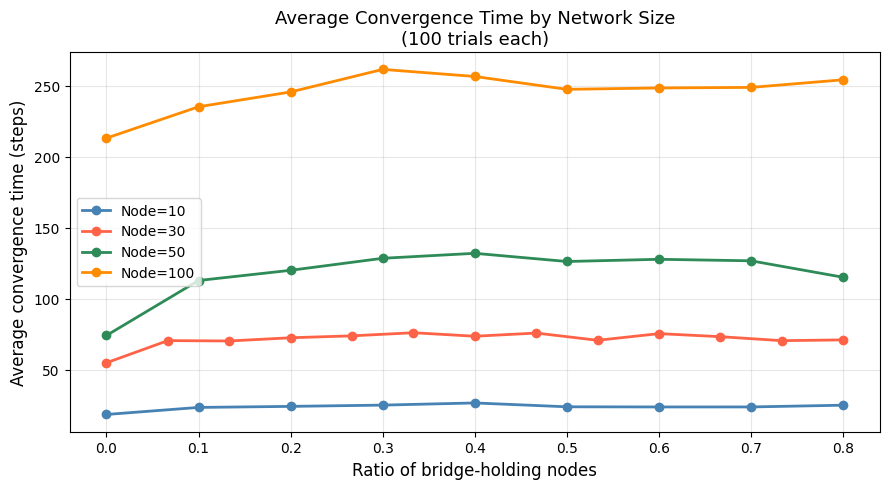

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

for (num_agents, (bridges, times)), color in zip(time_results.items(), colors):
    ratio = [b / num_agents for b in bridges]
    ax.plot(ratio, times, marker='o', color=color,
            linewidth=2, markersize=6, label=f'Node={num_agents}')

ax.set_xlabel("Ratio of bridge-holding nodes", fontsize=12)
ax.set_ylabel("Average convergence time (steps)", fontsize=12)
ax.set_title("Average Convergence Time by Network Size\n(100 trials each)", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()